<hr>
<h1 style="color:#1F618D; text-align:center;">
Health Disease Classification Using Machine Learning
</h1>
<p style="text-align:center; font-size:16px;">
Comparative Study of Random Forest, Naive Bayes and XGBoost
</p>
<hr>


<hr>
<h2 style="color:#2E86C1; text-align:center;">
1️⃣ IMPORTS
</h2>
<hr>


In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns


<hr>
<h2 style="color:#2E86C1; text-align:center;">
2️⃣ DATA LOADING
</h2>
<hr>


In [25]:
df = pd.read_csv("enterprise_health_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (80870, 833)


,patient_id,disease,age,gender,bmi,smoking_status,IBS_symptoms_severity,abdominal_bloating_severity,abdominal_cramps_severity,abdominal_discomfort_severity,...,wrist_pain_severity,writing_changes_severity,fever_days,cough_days,fatigue_days,headache_days,diarrhea_days,shortness_of_breath_days,nausea_days,body_ache_days
0,P00001,MRSA Infection,47,Male,25.7,Current,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,P00002,Mumps,3,Male,20.3,Never,0,0,0,0,...,0,0,8,0,5,2,0,0,0,0
2,P00003,Plantar Fasciitis,51,Male,23.7,Never,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,P00004,Otitis Media,2,Male,19.9,Never,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,P00005,Endocarditis,60,Female,27.7,Never,0,0,0,0,...,0,0,59,0,43,0,0,0,0,0


<hr>
<h2 style="color:#2E86C1; text-align:center;">
3️⃣ DATA PREPROCESSING
</h2>
<hr>


In [26]:
y = df["disease"]
X = df.drop(columns=["disease", "patient_id"], errors="ignore")

# One-hot encode categorical features
X = pd.get_dummies(X, columns=["gender", "smoking_status"], drop_first=True)

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Total Classes:", len(le.classes_))


Total Classes: 400


<hr>
<h2 style="color:#2E86C1; text-align:center;">4️⃣ TRAIN–TEST SPLIT</h2>
<hr>


In [27]:
y_series = pd.Series(y_encoded, index=X.index)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_series,
    test_size=0.2,
    random_state=42,
    stratify=y_series
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (64696, 832)
Test shape: (16174, 832)


<hr>
<h2 style="color:#2E86C1; text-align:center;">5️⃣ TRAINING DATA REDUCTION (SUBSAMPLING)</h2>
<hr>


In [28]:
X_small = X_train.sample(frac=0.7, random_state=42)
y_small = y_train.loc[X_small.index]

print("Reduced training size:", X_small.shape)


Reduced training size: (45287, 832)


<hr>
<h2 style="color:#2E86C1; text-align:center;">6️⃣ MODEL INITIALIZATION</h2>
<hr>


In [17]:
models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        n_jobs=-1,
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(
        n_estimators=60,
        max_depth=5,
        learning_rate=0.1,
        objective='multi:softmax',
        num_class=len(le.classes_),
        tree_method="hist",
        n_jobs=-1,
        random_state=42
    )
}


<hr>
<h2 style="color:#2E86C1; text-align:center;">
7️⃣ MODEL TRAINING & TEST EVALUATION
</h2>
<hr>


In [19]:
results = {}

for name, model in models.items():
    
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_small, y_small)
    
    # Predict on full test set
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")
    print("-"*50)



Training Random Forest...
Random Forest Accuracy: 0.9768
--------------------------------------------------

Training Naive Bayes...
Naive Bayes Accuracy: 0.9209
--------------------------------------------------

Training XGBoost...
XGBoost Accuracy: 0.9704
--------------------------------------------------


<hr>
<h2 style="color:#2E86C1; text-align:center;">
8️⃣ CROSS-VALIDATION ANALYSIS
</h2>
<hr>


In [20]:
cv_results = {}

for name, model in models.items():
    
    print(f"Running CV for {name}...")
    
    scores = cross_val_score(model, X_small, y_small, cv=3, n_jobs=-1)
    cv_results[name] = scores.mean()
    
    print(f"{name} CV Accuracy: {scores.mean():.4f}")
    print("-"*40)


Running CV for Random Forest...
Random Forest CV Accuracy: 0.9700
----------------------------------------
Running CV for Naive Bayes...
Naive Bayes CV Accuracy: 0.9328
----------------------------------------
Running CV for XGBoost...
XGBoost CV Accuracy: 0.9625
----------------------------------------


<hr>
<h2 style="color:#2E86C1; text-align:center;">
9️⃣ MODEL PERFORMANCE COMPARISON TABLE
</h2>
<hr>


In [21]:
comparison_df = pd.DataFrame({
    "Test Accuracy": pd.Series(results),
    "Cross-Validation Accuracy": pd.Series(cv_results)
})

comparison_df


,Test Accuracy,Cross-Validation Accuracy
Random Forest,0.976753,0.970036
Naive Bayes,0.920922,0.932784
XGBoost,0.970385,0.962506


<hr>
<h2 style="color:#2E86C1; text-align:center;">
🔟 MODEL PERFORMANCE VISUALIZATION
</h2>
<hr>


<Figure size 1000x600 with 0 Axes>

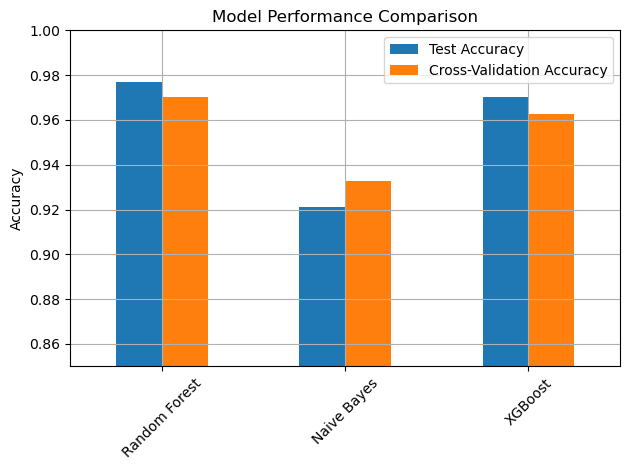

In [22]:
plt.figure(figsize=(10,6))

comparison_df.plot(
    kind="bar",
    ylim=(0.85, 1.0),
    grid=True,
    rot=45
)

plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()


<hr>
<h2 style="color:#2E86C1; text-align:center;">
1️⃣1️⃣ CLASSIFICATION REPORT — BEST MODEL (RANDOM FOREST)
</h2>
<hr>

In [29]:
best_model = models["Random Forest"]

y_pred = best_model.predict(X_test)

print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred))


Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      0.95      0.97        40
           2       0.95      1.00      0.98        40
           3       1.00      1.00      1.00        40
           4       1.00      0.98      0.99        42
           5       0.97      0.95      0.96        40
           6       0.85      0.97      0.91        40
           7       0.81      0.95      0.87        40
           8       1.00      1.00      1.00        40
           9       0.97      0.75      0.85        40
          10       0.80      0.97      0.88        40
          11       1.00      1.00      1.00        40
          12       1.00      1.00      1.00        40
          13       0.98      1.00      0.99        40
          14       0.95      0.97      0.96        40
          15       0.98      0.95      0.97        44
          16       1.00      1.00      1.0

<hr>
<h2 style="color:#2E86C1; text-align:center;">
1️⃣2️⃣ CONFUSION MATRIX — TOP 20 CLASSES (RANDOM FOREST)
</h2>
<hr>

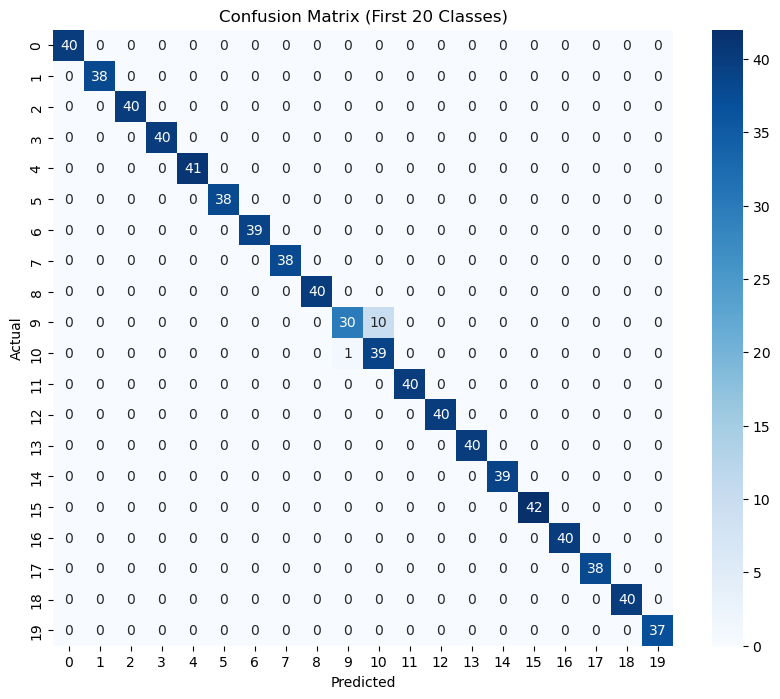

In [30]:
labels_subset = np.unique(y_test)[:20]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels_subset
)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues", annot=True, fmt="d")

plt.title("Confusion Matrix (First 20 Classes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


<hr>
<h2 style="color:#2E86C1; text-align:center;">1️⃣3️⃣ CONCLUSION</h2>
<hr>


### Key Findings

- Random Forest achieved the highest test accuracy (97.68%)
- XGBoost performed very closely (97.04%)
- Naive Bayes performed lower compared to ensemble models
- Cross-validation confirms model stability

### Final Model Selection

Random Forest was selected as the best-performing and most stable model.


<hr>
<h2 style="color:#2E86C1; text-align:center;">1️⃣4️⃣ SAVE TRAINED MODEL</h2>
<hr>


In [32]:
# 14 — SAVE TRAINED MODEL FOR CHATBOT DEPLOYMENT

import joblib

# Save best model (Random Forest)
joblib.dump(best_model, "disease_model.pkl")

# Save label encoder
joblib.dump(le, "label_encoder.pkl")

print("Model and encoder saved successfully!")


Model and encoder saved successfully!
